# Project 2 — Phase 1 evaluation notebook (NSL-KDD, MAE, One-Class SVM)

**Theme:** Signature matching fails on zero-day traffic; we learn a **hypersphere (margin) of normalcy** by (1) masked reconstruction on benign flow records and (2) an RBF One-Class SVM on frozen latent vectors.

**Stack in this notebook:** NSL-KDD (tabular flow features) · PyTorch (masked autoencoder) · scikit-learn (kernels, GMM, OCSVM) · matplotlib/seaborn (EDA).

**Scapy (live path):** Offline NSL-KDD uses *connection records* (the same statistical view IDS systems use after feature extraction). A **live** deployment would use **Scapy** to parse PCAPs into flow features before this pipeline—see the “Deployment” section below.

| Rubric axis | Where it is covered |
|-------------|---------------------|
| Literature review | Next section + theory recap at end |
| Dataset quality & EDA | NSL-KDD load, class balance, skew, plots |
| Feature engineering | `log1p` from skew audit; imputation + scaling + one-hot |
| Theoretical rigor | OCSVM ν & RBF RKHS, GMM/EM + BIC, MAE masking, MAE/RMSE |
| Model application | Baseline z-score · GMM · OCSVM(raw) · MAE recon · Hybrid |

## Literature (cite these in your LaTeX report)

1. **Chandola, Banerjee & Kumar** — *Anomaly Detection: A Survey* (ACM CSUR, 2009): taxonomy, evaluation caveats.  
2. **Schölkopf et al.** — *Estimating the Support of a High-Dimensional Distribution* (Neural Comp., 2001): ν-OCSVM.  
3. **Tax & Duin** — *Support Vector Data Description* (ML, 2004): hypersphere / margin intuition.  
4. **Vincent et al.** — *Stacked Denoising Autoencoders* (ICML 2008): reconstruction + corruption (linked to masked denoising).  
5. **Devlin et al. (BERT)** — *Pre-training of Deep Bidirectional Transformers* (NAACL 2019): masked-token objective—we apply the **same idea to tabular flow features** (random feature masking).  
6. **Tavallaee et al.** — *NSL-KDD* (2012): dataset motivation (reduced redundancy vs KDD’99).  
7. **Mahoney & Chan** (RAID 2002): non-stationarity / limits of KDD-era benchmarks—use as **honest limitation**.

**Synthesis for your story:** Normal traffic occupies a **low-volume manifold** in feature space. A **masked autoencoder** learns local geometry by denoising; **OCSVM with RBF** defines a **smooth boundary** around benign latents (hypersphere in RKHS). High **reconstruction error** under the frozen encoder and **negative margin** jointly indicate “far from normal.”

## Architecture (course diagram)

```mermaid
flowchart LR
  subgraph ingest [Ingest]
    PCAP[Optional: PCAP via Scapy] --> FEAT[Flow feature vector]
    NSL[NSL-KDD CSV row] --> FEAT
  end
  FEAT --> LOG[Skew-driven log1p]
  LOG --> TAB[Impute + scale + one-hot]
  TAB -->|benign only| MAE[Masked autoencoder pretrain]
  MAE --> Z[Latent embedding z]
  TAB -->|benign only| OCr[One-Class SVM on raw x]
  Z -->|benign only| OCz[One-Class SVM on z]
  MAE --> RE[Per-sample recon MSE]
  RE --> HY[Hybrid score]
  OCz --> HY
  HY --> OUT[Anomaly decision + metrics]
```

**Deliverable mapping:** **Model A** = advanced classical (here: OCSVM on raw *x*; we also report GMM + Mahalanobis). **Model B** = deep learning signal only (reconstruction / RMSE threshold). **Model C** = **hybrid** (normalized recon + OCSVM-on-*z*).

## Deployment note: Scapy vs NSL-KDD

- **NSL-KDD** rows are *already aggregated TCP/IP connection statistics* (duration, bytes, flags, rates, …)—ideal for reproducible coursework.  
- **Scapy** (`from scapy.all import sniff, IP, TCP`) fits the **operational story**: capture packets on an interface, aggregate to the same statistical schema (or to a fixed-length byte window for a future sequence encoder).  
- Phase 1 uses NSL for **EDA + model validation**; cite Scapy in **methods** as the bridge to **live industrial / IoT** monitoring.

In [1]:
from __future__ import annotations

import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display
from sklearn.model_selection import train_test_split

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from cps_ad.advanced_ml import GaussianMixtureAnomalyDetector, OneClassSvmAnomalyDetector
from cps_ad.baselines import MahalanobisAnomalyDetector, max_zscore_anomaly_score
from cps_ad.hybrid_scores import fit_ocsvm_latent, hybrid_score, ocsvm_latent_scores
from cps_ad.metrics import best_f1_threshold, evaluate_scores
from cps_ad.nsl_kdd import frames_to_xy, load_nsl_kdd_frames
from cps_ad.phase1 import select_gmm_components_by_bic
from cps_ad.preprocess import apply_log1p_columns, build_preprocess_pipeline, numeric_skewness
from cps_ad.torch_mae import latent_matrix, reconstruction_mse_per_sample, train_mae_benign

sns.set_theme(style="whitegrid", context="notebook")
%matplotlib inline

RANDOM_STATE = 42
TRAIN_VARIANT = "twenty"  # "full" for entire KDDTrain+ (~19MB download)
np.random.seed(RANDOM_STATE)

def dense(x):
    return x.toarray() if hasattr(x, "toarray") else np.asarray(x)

print("ROOT =", ROOT)

ROOT = /Users/kartikyadav/Desktop/Newtypeorgs/dl-aml-cybersec-project


## Load NSL-KDD (automatic download to `data/nsl/` on first run)

In [2]:
train_df, test_df = load_nsl_kdd_frames(download=True, train_variant=TRAIN_VARIANT)
X_train_df, y_train, X_test_df, y_test = frames_to_xy(train_df, test_df)

display(Markdown(
    f"**Train** `{X_train_df.shape}` · attack rate **{y_train.mean():.3f}**  \n"
    f"**Test (NSL KDDTest+)** `{X_test_df.shape}` · attack rate **{y_test.mean():.3f}**"
))
X_train_df.head(3)

**Train** `(25192, 41)` · attack rate **0.466**  
**Test (NSL KDDTest+)** `(22544, 41)` · attack rate **0.569**

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,150,25,0.17,0.03,0.17,0.0,0.0,0.0,0.05,0.0
1,0,udp,other,SF,146,0,0,0,0,0,...,255,1,0.00,0.60,0.88,0.0,0.0,0.0,0.00,0.0
2,0,tcp,private,S0,0,0,0,0,0,0,...,255,26,0.10,0.05,0.00,0.0,1.0,1.0,0.00,0.0


### EDA (interpret, don’t only print)

We quantify **class imbalance**, **numeric skew** (drives `log1p`), and **label-conditional** marginals. NSL-KDD is **not IID over time** (Mahoney & Chan); treat global train/test split as a **benchmark protocol**, not a deployment guarantee.

,count
normal,13449
attack,11743


,fraction
normal,0.53386
attack,0.46614


**Top skewed numeric columns (tail heaviness):**

,skew
urgent,158.719879
src_bytes,157.558542
land,112.225219
num_root,62.321064
num_compromised,62.191088
dst_bytes,54.777576
num_failed_logins,53.312608
num_shells,52.881419
num_file_creations,52.141688
num_access_files,41.752764


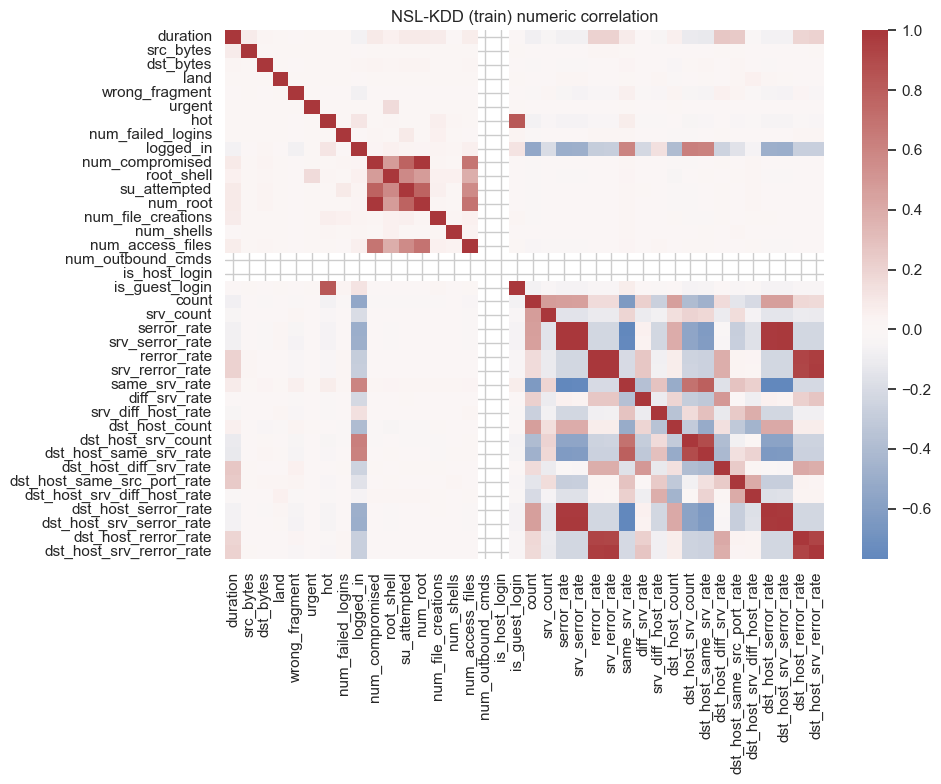

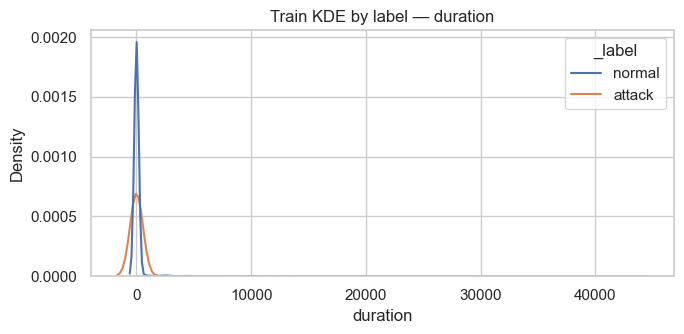

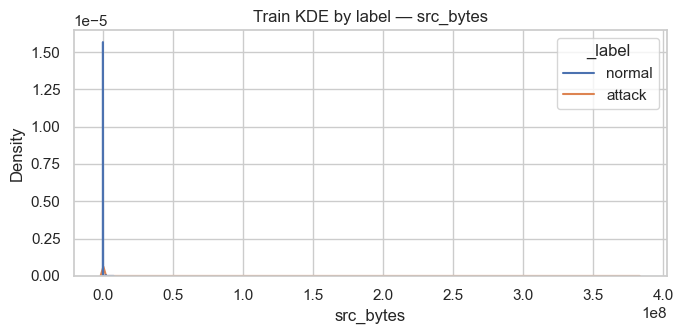

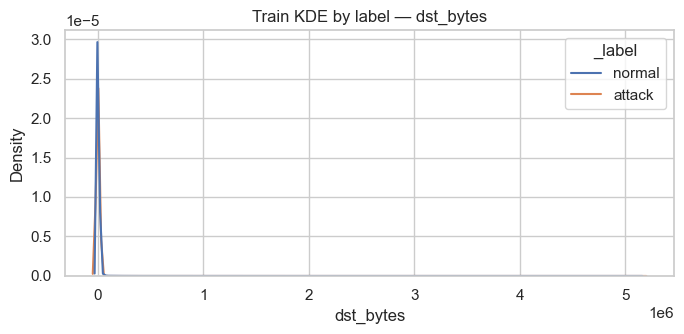

In [3]:
labels_tr = np.where(y_train == 0, "normal", "attack")
display(pd.Series(labels_tr).value_counts().to_frame("count"))
display(pd.Series(labels_tr).value_counts(normalize=True).to_frame("fraction"))

skew = numeric_skewness(X_train_df)
display(Markdown("**Top skewed numeric columns (tail heaviness):**"))
display(skew.head(10).to_frame("skew"))

FIG = ROOT / "reports" / "figures"
FIG.mkdir(parents=True, exist_ok=True)

num = X_train_df.select_dtypes(include=[np.number])
if num.shape[1] >= 2:
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(num.corr(numeric_only=True), cmap="vlag", center=0.0, ax=ax)
    ax.set_title("NSL-KDD (train) numeric correlation")
    plt.tight_layout()
    fig.savefig(FIG / "phase1_nsl_corr.png", dpi=150, bbox_inches="tight")
    plt.show()

sample_cols = [c for c in ["duration", "src_bytes", "dst_bytes", "count"] if c in X_train_df.columns]
plot_df = X_train_df[sample_cols].copy()
plot_df["_label"] = labels_tr
for c in sample_cols[:3]:
    fig, ax = plt.subplots(figsize=(7, 3.5))
    sns.kdeplot(data=plot_df, x=c, hue="_label", common_norm=False, ax=ax)
    ax.set_title(f"Train KDE by label — {c}")
    plt.tight_layout()
    fig.savefig(FIG / f"phase1_nsl_kde_{c}.png", dpi=150, bbox_inches="tight")
    plt.show()

### Feature engineering

1. `log1p` on top-k skewed numerics (train-driven).  
2. **ColumnTransformer:** median imputer + `StandardScaler` on numeric columns; `OneHotEncoder(handle_unknown="ignore")` on symbolic fields (`protocol_type`, `service`, `flag`).  
3. **Leakage control:** the transformer is **fit only on benign** training rows; attacks in the training split never influence scaling / categories.

In [4]:
log_cols = list(skew.head(4).index)
X_train_fe, skew_reports = apply_log1p_columns(X_train_df, log_cols)
X_test_fe, _ = apply_log1p_columns(X_test_df, log_cols)
for s in skew_reports:
    print(f"log1p {s.column}: skew {s.skew_before:.3f} → {s.skew_after:.3f}")

idx = np.arange(len(y_train))
tr, va = train_test_split(idx, test_size=0.15, stratify=y_train, random_state=RANDOM_STATE)
x_tr = X_train_fe.iloc[tr]
x_va = X_train_fe.iloc[va]
y_tr = y_train[tr]
y_va = y_train[va]

benign_tr = y_tr == 0
x_fit_df = x_tr.iloc[benign_tr]

pre = build_preprocess_pipeline(x_fit_df)
pre.fit(x_fit_df)

X_tr_t = dense(pre.transform(x_tr))
X_va_t = dense(pre.transform(x_va))
X_te_t = dense(pre.transform(X_test_fe))
X_fit_t = X_tr_t[benign_tr]

print("Transformed shapes:", X_tr_t.shape, X_va_t.shape, X_te_t.shape)

log1p urgent: skew 158.720 → 158.720
log1p src_bytes: skew 157.559 → 0.313
log1p land: skew 112.225 → 112.225
log1p num_root: skew 62.321 → 24.350
Transformed shapes: (21413, 72) (3779, 72) (22544, 72)


### Advanced ML (raw feature space, benign-only fit)

- **Max-|z|:** column-wise z vs benign mean/std.  
- **Mahalanobis:** Ledoit–Wolf shrinkage covariance (stabilizes inverse in high *d* after one-hot).  
- **GMM:** EM with **diagonal** covariances per component; **BIC** selects `K` on benign training data.  
- **One-Class SVM (RBF):** ν upper-bounds the fraction of **margin errors / SVs** on the training set; `gamma="scale"` uses `1 / (d · Var(X))`.

In [5]:
mu = X_fit_t.mean(axis=0)
sigma = X_fit_t.std(axis=0)
s_va_z = max_zscore_anomaly_score(X_va_t, mu=mu, sigma=sigma)
s_te_z = max_zscore_anomaly_score(X_te_t, mu=mu, sigma=sigma)

maha = MahalanobisAnomalyDetector().fit(X_fit_t)
s_va_m = maha.score_samples(X_va_t)
s_te_m = maha.score_samples(X_te_t)

best_k, bic_map = select_gmm_components_by_bic(
    X_fit_t, components_range=range(2, 8), random_state=RANDOM_STATE
)
gmm = GaussianMixtureAnomalyDetector(n_components=best_k, random_state=RANDOM_STATE).fit(X_fit_t)
s_va_g = gmm.score_samples(X_va_t)
s_te_g = gmm.score_samples(X_te_t)

ocsvm_raw = OneClassSvmAnomalyDetector(nu=0.08, gamma="scale").fit(X_fit_t)
s_va_r = ocsvm_raw.score_samples(X_va_t)
s_te_r = ocsvm_raw.score_samples(X_te_t)

print("GMM BIC by K:")
for k, v in sorted(bic_map.items()):
    print(f"  K={k}: BIC={v:.1f}")
print("Selected K =", best_k)

GMM BIC by K:
  K=2: BIC=-3777434.4
  K=3: BIC=-4747474.4
  K=4: BIC=-5484860.3
  K=5: BIC=-5356362.9
  K=6: BIC=-5526942.9
  K=7: BIC=-6432622.8
Selected K = 7


### Deep learning — masked autoencoder (BERT-style masking on tabular *x*)

- **Objective:** mask a random fraction of input coordinates; minimize **MSE only on masked positions** (denoising).  
- **Regularization:** dropout + **BatchNorm** + **AdamW** weight decay; **early stopping** on benign validation masked loss.  
- **Init:** Xavier uniform on linear layers.  
- **Scoring (Model B):** full-vector reconstruction **MSE** (RMSE = sqrt(MSE) for reporting).

In [6]:
val_normal_mask = y_va == 0
X_val_normal = X_va_t[val_normal_mask]

mae_result = train_mae_benign(
    X_fit_t,
    X_val_normal,
    mask_prob=0.25,
    epochs=40,
    batch_size=512,
    lr=1e-3,
    weight_decay=1e-4,
    patience=6,
    seed=RANDOM_STATE,
    device="cpu",
)
mae_model = mae_result.model
print("MAE early-stop epoch (0-based):", mae_result.best_epoch, "  val history len:", len(mae_result.history))

recon_va = reconstruction_mse_per_sample(mae_model, X_va_t, device="cpu")
recon_te = reconstruction_mse_per_sample(mae_model, X_te_t, device="cpu")
rmse_va = np.sqrt(recon_va)
rmse_te = np.sqrt(recon_te)
print("Benign-val recon RMSE median:", float(np.median(rmse_va[val_normal_mask])))

MAE early-stop epoch (0-based): 6   val history len: 13
Benign-val recon RMSE median: 0.19153858721256256


### Hybrid — OCSVM on **frozen** latent *z* + reconstruction

1. `z = encoder(x)` for all splits (encoder weights frozen after MAE training).  
2. Fit **RBF OCSVM** on benign `z_train`.  
3. **Normalize** recon error and OCSVM scores using min–max stats from **benign validation** only.  
4. **Tune** convex weight `w` on validation F1 (small grid).

In [7]:
Z_fit = latent_matrix(mae_model, X_fit_t, device="cpu")
Z_va = latent_matrix(mae_model, X_va_t, device="cpu")
Z_te = latent_matrix(mae_model, X_te_t, device="cpu")

ocsvm_z, z_scaler = fit_ocsvm_latent(Z_fit, nu=0.08, gamma="scale")
s_va_zoc = ocsvm_latent_scores(ocsvm_z, z_scaler, Z_va)
s_te_zoc = ocsvm_latent_scores(ocsvm_z, z_scaler, Z_te)

ref = y_va == 0
best_w, best_f1v = 0.5, -1.0
for w in np.linspace(0.15, 0.85, 15):
    hva = hybrid_score(recon_va, s_va_zoc, recon_ref=recon_va[ref], ocsvm_ref=s_va_zoc[ref], w_recon=float(w))
    _, f1v = best_f1_threshold(y_va, hva)
    if f1v > best_f1v:
        best_f1v, best_w = f1v, float(w)

hy_va = hybrid_score(
    recon_va, s_va_zoc, recon_ref=recon_va[ref], ocsvm_ref=s_va_zoc[ref], w_recon=best_w
)
hy_te = hybrid_score(
    recon_te, s_te_zoc, recon_ref=recon_va[ref], ocsvm_ref=s_va_zoc[ref], w_recon=best_w
)
print("Selected hybrid w_recon =", best_w, "  val F1 (oracle thr) =", round(best_f1v, 4))

Selected hybrid w_recon = 0.85   val F1 (oracle thr) = 0.9216


### Metrics & **ablation table** (course Models A / B / C)

We tune a **single threshold per model** on the **validation** split (max F1), then report **test** ROC-AUC / PR-AUC / F1 at that threshold.  
**Model A:** One-Class SVM on raw scaled features (also compare GMM / Mahalanobis in auxiliary rows).  
**Model B:** MAE reconstruction MSE only.  
**Model C:** Hybrid (tuned `w_recon` + OCSVM on *z*).

In [8]:
rows = []


def row(name: str, s_va: np.ndarray, s_te: np.ndarray) -> None:
    thr, f1v = best_f1_threshold(y_va, s_va)
    m = evaluate_scores(y_test, s_te, threshold=thr)
    rows.append(
        {
            "model": name,
            "val_thr": thr,
            "val_f1_tune": f1v,
            "test_roc_auc": m.roc_auc,
            "test_pr_auc": m.pr_auc,
            "test_f1": m.f1,
            "test_precision": m.precision,
            "test_recall": m.recall,
        }
    )


row("A_advanced_ocsvm_raw_x", s_va_r, s_te_r)
row("B_dl_mae_recon_mse", recon_va, recon_te)
row("C_hybrid_recon_plus_ocsvm_z", hy_va, hy_te)

aux = []
for name, sva, ste in [
    ("aux_baseline_max_zscore", s_va_z, s_te_z),
    ("aux_mahalanobis_shrunk", s_va_m, s_te_m),
    ("aux_gmm_nll", s_va_g, s_te_g),
]:
    thr, f1v = best_f1_threshold(y_va, sva)
    m = evaluate_scores(y_test, ste, threshold=thr)
    aux.append({"model": name, "test_roc_auc": m.roc_auc, "test_f1": m.f1})

ablation_df = pd.DataFrame(rows).set_index("model")
display(Markdown("### Required ablation (A / B / C)"))
display(ablation_df)

display(Markdown("### Auxiliary baselines (Phase-1 depth)"))
display(pd.DataFrame(aux).set_index("model"))

out = ROOT / "reports" / "phase1_ablation_nsl.json"
out.parent.mkdir(parents=True, exist_ok=True)
payload = {
    "ablation_main": rows,
    "ablation_aux": aux,
    "gmm_bic": {str(k): v for k, v in bic_map.items()},
    "gmm_k": best_k,
    "hybrid_w_recon": best_w,
    "train_variant": TRAIN_VARIANT,
    "random_state": RANDOM_STATE,
}
out.write_text(json.dumps(payload, indent=2), encoding="utf-8")
print("Wrote", out)

### Required ablation (A / B / C)

,val_thr,val_f1_tune,test_roc_auc,test_pr_auc,test_f1,test_precision,test_recall
model,,,,,,,
A_advanced_ocsvm_raw_x,2.531328,0.931792,0.920359,0.941817,0.846059,0.929064,0.776670
B_dl_mae_recon_mse,0.566062,0.918052,0.942441,0.944095,0.831863,0.923457,0.756799
C_hybrid_recon_plus_ocsvm_z,0.061839,0.921574,0.781210,0.878504,0.812316,0.934245,0.718538


### Auxiliary baselines (Phase-1 depth)

,test_roc_auc,test_f1
model,,
aux_baseline_max_zscore,0.927582,0.894006
aux_mahalanobis_shrunk,0.950259,0.863625
aux_gmm_nll,0.923397,0.802933


Wrote /Users/kartikyadav/Desktop/Newtypeorgs/dl-aml-cybersec-project/reports/phase1_ablation_nsl.json


### Theory recap (viva cheatsheet)

| Component | Assumption / mechanism | What to say under probing |
|-----------|------------------------|---------------------------|
| **Masked AE** | Empirical denoising; no exact probabilistic model | Masks break identity shortcut; forces **compression** in `z`. |
| **RBF kernel** | Implicit feature map Φ; boundary in RKHS | Smooth boundary; ν controls **support vs. outliers** trade-off. |
| **GMM + EM** | Mixture of Gaussians; local max of likelihood | EM monotonic on incomplete-data ELBO; **BIC** penalizes `K`. |
| **Mahalanobis** | Approx. elliptical benign cloud | Shrinkage when *d* is large / ill-conditioned Σ. |

**Violations:** NSL attacks are **not** a single homogeneous “out” class; train/test protocol **differs** (known issue in NSL papers)—discuss **concept drift** as extra-mile future work.

### Optional: Scapy one-liner (PCAP → experimentation)

Not executed here (needs root / live capture). For your report or Phase 3 demo:

```python
# pip install scapy
from scapy.all import rdpcap, TCP, IP
pkts = rdpcap("capture.pcap", count=5000)
# Aggregate to flow keys (5-tuple) and compute duration, byte counts, flags → same schema as NSL-style IDS features.
```

**Next phases:** sequence encoder (1D-CNN / Transformer) on byte windows; drift detection (ADWIN, KL alarm); FGSM on *z* for adversarial robustness.